# Benchmarking Harpia Module for Annotat3d Image Processing and Segmentation

This notebook benchmarks the **Harpia module**, the backend engine for Annotat3d, a tool designed for advanced image processing and segmentation tasks. The benchmarking process evaluates two key performance metrics:

1. **Accuracy**: Compares the results of Harpia’s image processing and segmentation functions with standard open-source tools like `scikit-image`, ensuring reliability and accuracy that meet industry standards.

2. **Execution Time**: Assesses runtime efficiency by measuring the execution times of Harpia’s functions relative to baseline tools, especially when handling large or complex images.

The benchmark is conducted on both **2D and 3D images** of various sizes, including very large images, to reflect Sirius demands in high-resolution and volumetric data efficient processing. This notebook provides a step-by-step analysis, including data setup, function execution, and results comparison, to evaluate Harpia's capability to handle a range of image dimensions and formats.


## Read all tests

In [1]:
import os
import pandas as pd
import glob

def read_csv_files():
    # Get the current working directory
    current_dir = os.getcwd()
    print("Searching in:", current_dir)

    # Recursively find all CSV files in subdirectories
    csv_files = glob.glob(os.path.join(current_dir, "**", "*.csv"), recursive=True)

    if not csv_files:
        print("No CSV files found.")
        return None

    # Read all CSV files into a list of DataFrames
    dfs = [pd.read_csv(file) for file in csv_files]

    # Optionally, concatenate all DataFrames into one
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Loaded {len(csv_files)} CSV files.")
    return df_all

# Example usage
df = read_csv_files()


Searching in: /ibira/lnls/labs/tepui/home/camila.araujo/work/harpia/tests_python/benchmark
Loaded 219 CSV files.


In [2]:
df['Image Dimensions'].unique()

array(['(1964, 2048, 2048)', '(1520, 1520, 600)', '(100, 207, 190)',
       '(2048, 2052, 2052)'], dtype=object)

In [3]:
df[df['Image Dimensions'] == '(2048, 2052, 2052)'] #big image

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions
120,Closing 3D binary,harriet,1,0.2,28.519186,339.915684,11.9,10,0.0,100.0,uint32,32896.1,"(2048, 2052, 2052)"
121,Erosion 3D binary,harriet,2,0.2,14.796998,155.746572,10.5,10,0.0,100.0,int16,16448.1,"(2048, 2052, 2052)"
122,Erosion 3D grayscale,harriet,2,0.2,9.104506,268.842347,29.5,10,0.0,100.0,float32,32896.1,"(2048, 2052, 2052)"
123,Dilation 3D grayscale,harriet,4,0.2,18.454371,NaN,NaN,10,NaN,NaN,float32,32896.1,"(2048, 2052, 2052)"
124,Dilation 3D binary,harriet,1,0.2,6.069428,142.815209,23.5,10,0.0,100.0,int16,16448.1,"(2048, 2052, 2052)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,Erosion 3D grayscale,harriet,1,0.2,25.619439,301.766232,11.8,10,0.0,100.0,uint32,32896.1,"(2048, 2052, 2052)"
215,Opening 3D binary,harriet,1,0.2,17.907504,325.735123,18.2,10,0.0,100.0,int32,32896.1,"(2048, 2052, 2052)"
216,Closing 3D binary,harriet,4,0.2,19.899343,NaN,NaN,10,NaN,NaN,uint32,32896.1,"(2048, 2052, 2052)"
217,Closing 3D grayscale,harriet,4,0.2,22.451185,NaN,NaN,10,NaN,NaN,float32,32896.1,"(2048, 2052, 2052)"


In [4]:
df[df['Image Dimensions'] == '(100, 207, 190)'] #small image

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions
36,Smoothing 3D binary,harriet,1,0.2,0.010380,0.226694,21.8,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
37,Opening 3D binary,harriet,1,0.2,0.004046,0.086353,21.3,10,0.0,100.0,uint8,3.8,"(100, 207, 190)"
38,Opening 3D binary,harriet,1,0.2,0.004510,0.088112,19.5,10,0.0,100.0,int8,3.8,"(100, 207, 190)"
39,Erosion 3D grayscale,harriet,1,0.2,0.005448,0.107222,19.7,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
40,Erosion 3D binary,harriet,2,0.2,0.004184,0.043281,10.3,10,0.0,100.0,uint16,7.5,"(100, 207, 190)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Dilation 3D grayscale,harriet,2,0.2,0.005916,0.105252,17.8,10,0.0,100.0,float32,15.0,"(100, 207, 190)"
116,Dilation 3D binary,harriet,2,0.2,0.004315,0.037975,8.8,10,0.0,100.0,int16,7.5,"(100, 207, 190)"
117,Closing 3D binary,harriet,2,0.2,0.007798,0.081699,10.5,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
118,Erosion 3D grayscale,harriet,1,0.2,0.005600,0.102188,18.2,10,0.0,100.0,float32,15.0,"(100, 207, 190)"


## Clean dataframe

In [5]:
df.columns

Index(['Operation', 'Machine', 'Gpus', 'gpuMemory', 'Module Time (s)',
       'Scikit-Image Time (s)', 'Time Ratio', 'Repetitions',
       'Mean Squared Error', 'Pixel Accuracy (%)', 'Image Data Type',
       'Image Size (MB)', 'Image Dimensions'],
      dtype='object')

Preencher as colunas que não possuem o tempo de execução no scikit image com a média do cálculo já feito para a mesma imagem e mesmo tamanho em outros casos.

In [6]:
df['Scikit-Image Time (s)'] = df['Scikit-Image Time (s)'].fillna(
    df.groupby(['Image Data Type', 'Image Size (MB)', 'Image Dimensions'])['Scikit-Image Time (s)'].transform('mean')
)

Preencher o 'time ratio' aproximado para as funções que não calcularam concomitnatemente o resultado do scikit image

In [7]:
df['Time Ratio'] = df['Time Ratio'].fillna(df['Scikit-Image Time (s)'] / df['Module Time (s)'])

Remover valores NaN. São majoritariamente das imagens de dimensões (1964, 2048, 2048) e (1520, 1520, 600) para as quais os teste não foram completos.

In [8]:
df = df.dropna(subset=['Time Ratio'])

In [9]:
df

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions
36,Smoothing 3D binary,harriet,1,0.2,0.010380,0.226694,21.800000,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
37,Opening 3D binary,harriet,1,0.2,0.004046,0.086353,21.300000,10,0.0,100.0,uint8,3.8,"(100, 207, 190)"
38,Opening 3D binary,harriet,1,0.2,0.004510,0.088112,19.500000,10,0.0,100.0,int8,3.8,"(100, 207, 190)"
39,Erosion 3D grayscale,harriet,1,0.2,0.005448,0.107222,19.700000,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
40,Erosion 3D binary,harriet,2,0.2,0.004184,0.043281,10.300000,10,0.0,100.0,uint16,7.5,"(100, 207, 190)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,Erosion 3D grayscale,harriet,1,0.2,25.619439,301.766232,11.800000,10,0.0,100.0,uint32,32896.1,"(2048, 2052, 2052)"
215,Opening 3D binary,harriet,1,0.2,17.907504,325.735123,18.200000,10,0.0,100.0,int32,32896.1,"(2048, 2052, 2052)"
216,Closing 3D binary,harriet,4,0.2,19.899343,368.214004,18.503827,10,NaN,NaN,uint32,32896.1,"(2048, 2052, 2052)"
217,Closing 3D grayscale,harriet,4,0.2,22.451185,405.161566,18.046333,10,NaN,NaN,float32,32896.1,"(2048, 2052, 2052)"


## plots

In [12]:
image_dims = df['Image Dimensions'].unique()
image_dims

array(['(100, 207, 190)', '(2048, 2052, 2052)'], dtype=object)

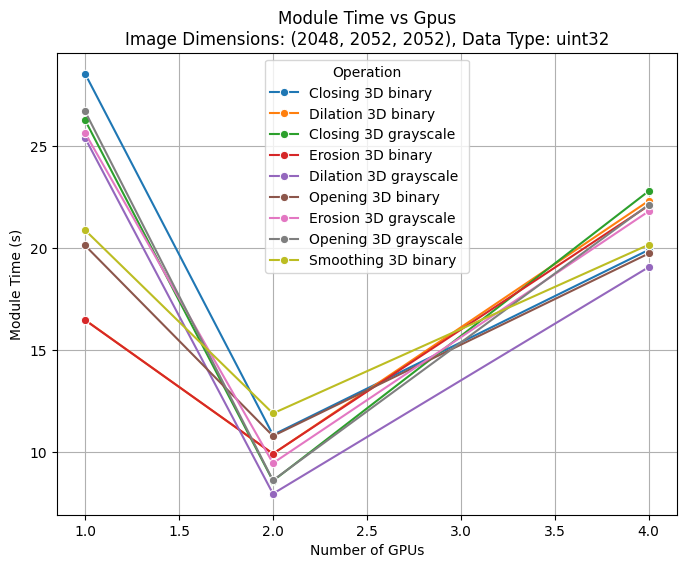

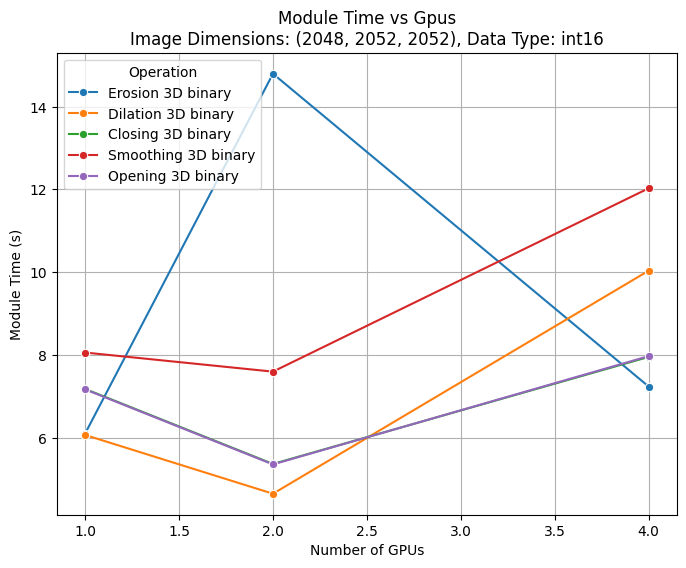

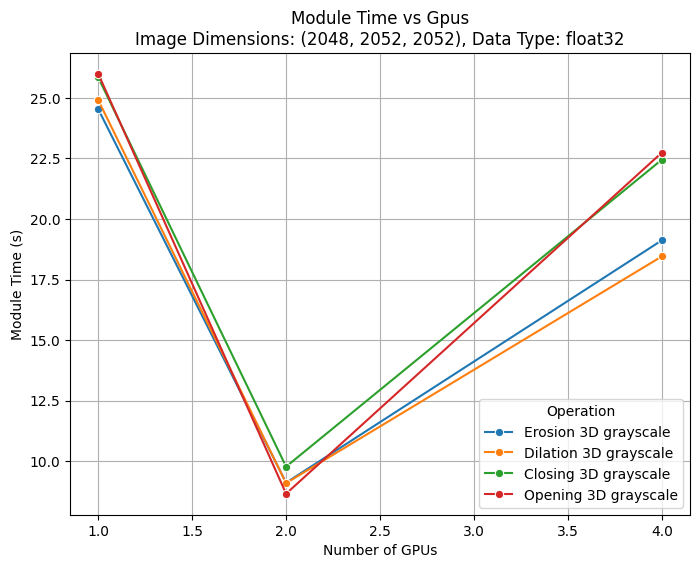

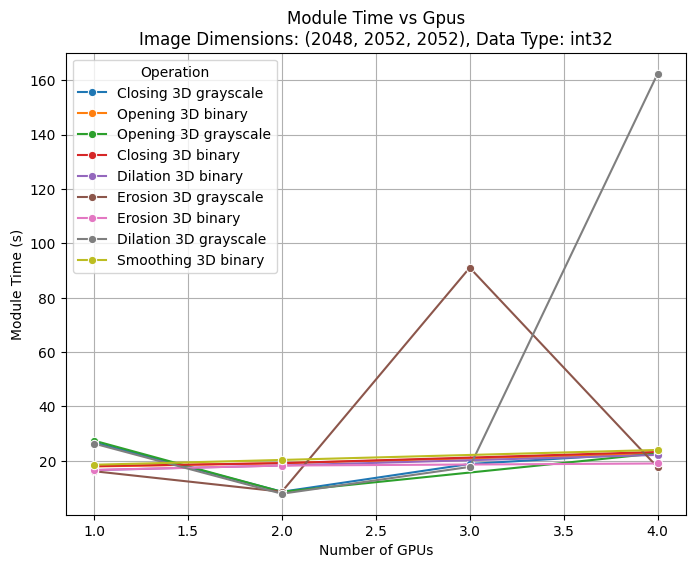

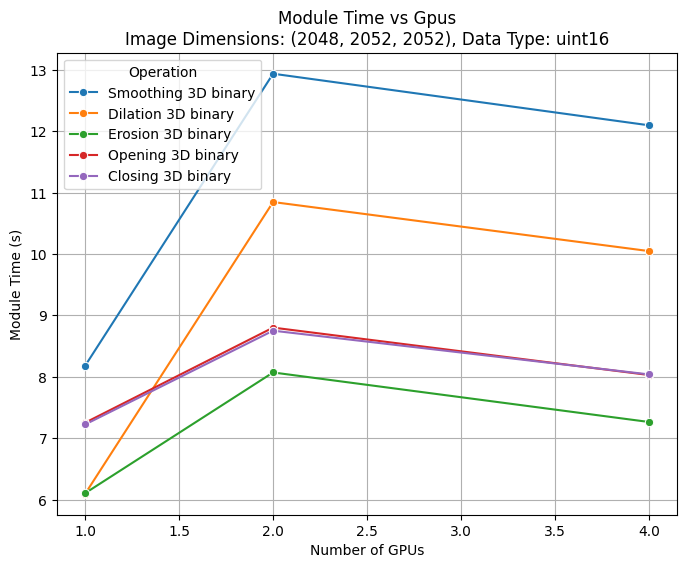

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_huge = df[df['Image Dimensions'] == '(2048, 2052, 2052)']
# Get unique values of 'Image Dimensions' and 'Image Data Type'
image_dims = df_huge['Image Dimensions'].unique()
data_types = df_huge['Image Data Type'].unique()

# Create plots for each combination of Image Dimensions and Image Data Type
for img_dim in ['(2048, 2052, 2052)']:
    for dtype in data_types:
        plt.figure(figsize=(8, 6))
        subset = df_huge[(df_huge['Image Dimensions'] == img_dim) & (df_huge['Image Data Type'] == dtype)]

        sns.lineplot(data=subset, x='Gpus', y='Module Time (s)', hue='Operation', marker='o')

        plt.title(f"Module Time vs Gpus\nImage Dimensions: {img_dim}, Data Type: {dtype}")
        plt.xlabel("Number of GPUs")
        plt.ylabel("Module Time (s)")
        plt.legend(title="Operation")
        plt.grid(True)
        plt.show()

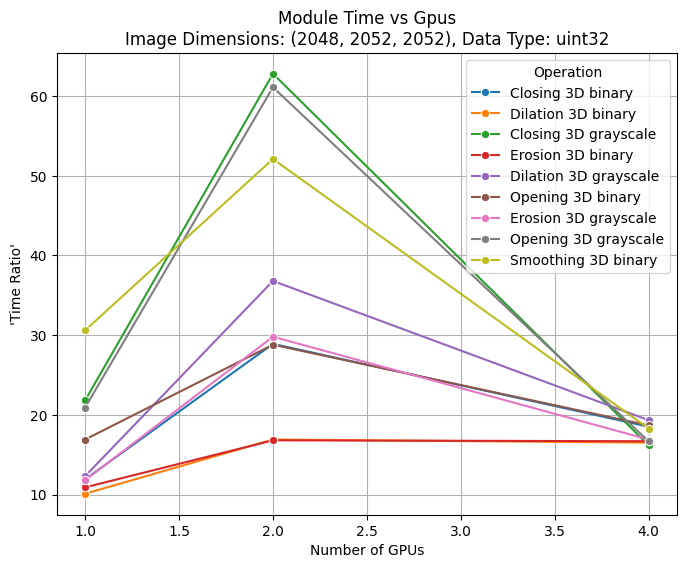

/tmp/ipykernel_3928213/2248849714.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Operation")


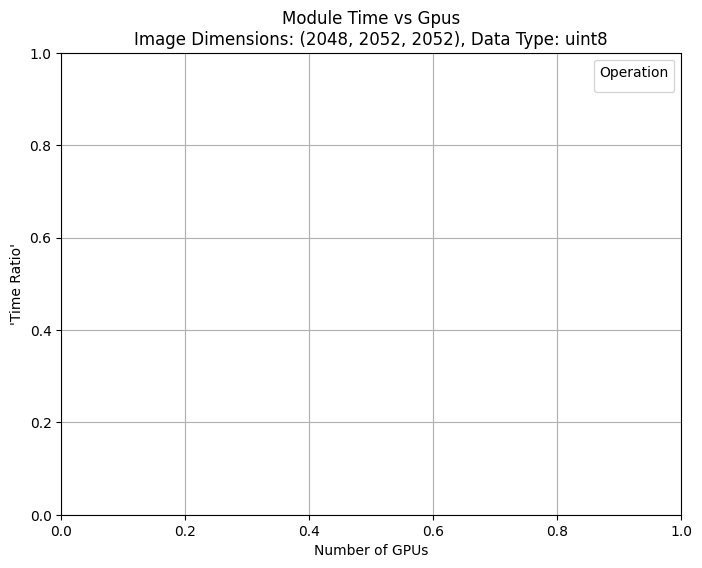

/tmp/ipykernel_3928213/2248849714.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Operation")


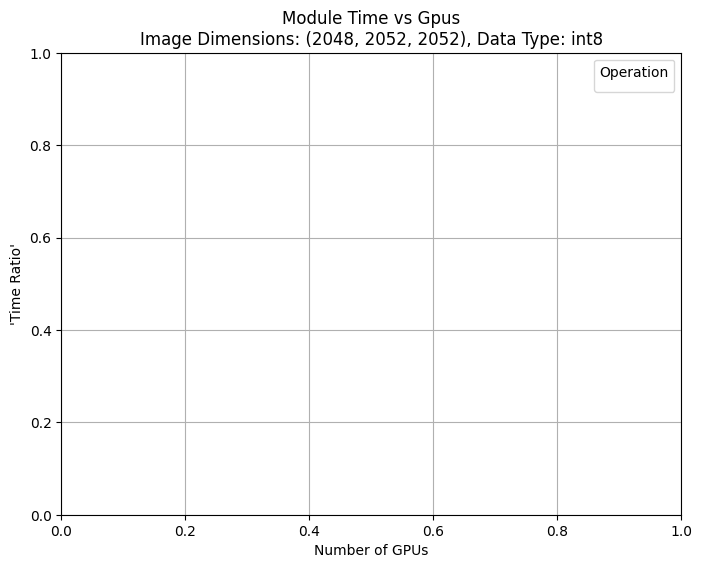

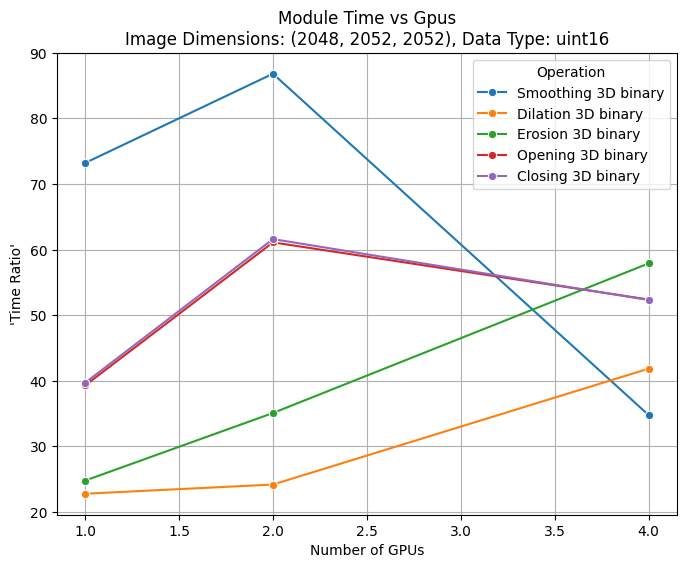

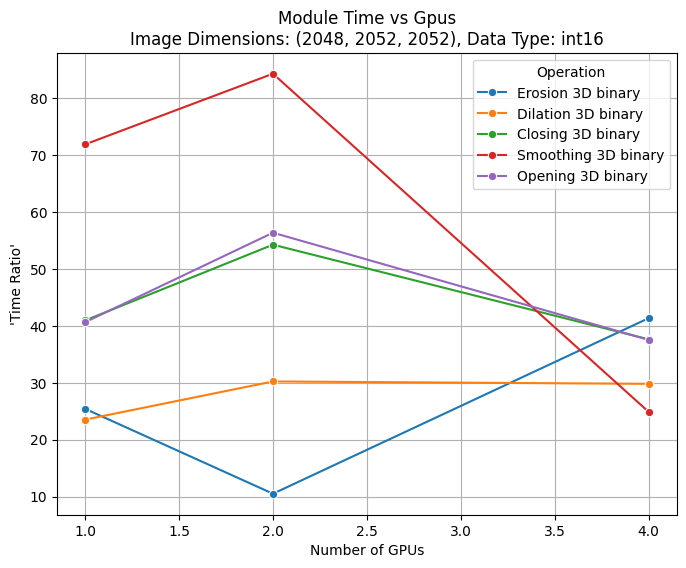

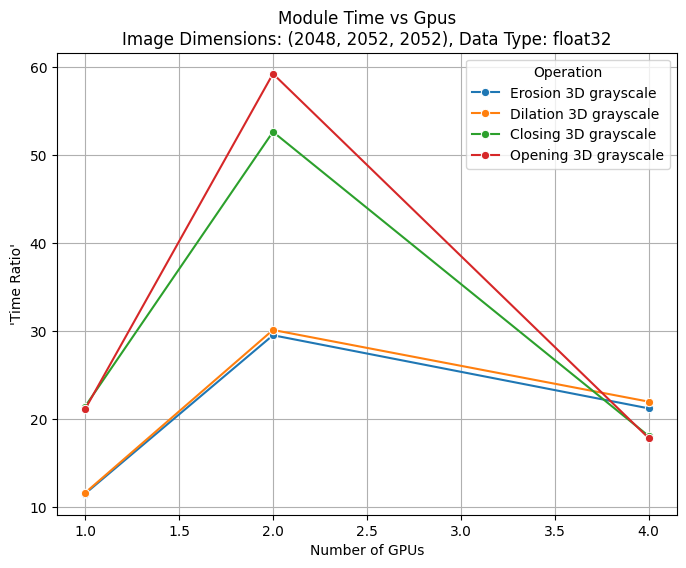

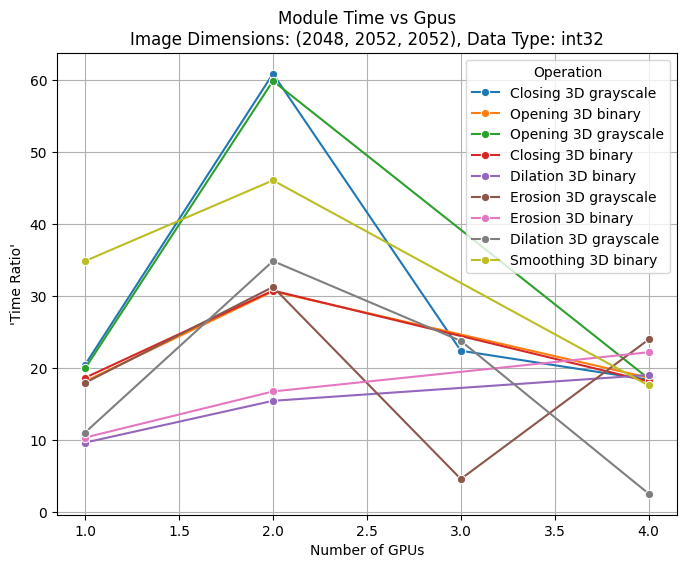

In [18]:
# Get unique values of 'Image Dimensions' and 'Image Data Type'
image_dims = df['Image Dimensions'].unique()
data_types = df['Image Data Type'].unique()

# Create plots for each combination of Image Dimensions and Image Data Type
for img_dim in ['(2048, 2052, 2052)']:
    for dtype in data_types:
        plt.figure(figsize=(8, 6))
        subset = df[(df['Image Dimensions'] == img_dim) & (df['Image Data Type'] == dtype)]

        sns.lineplot(data=subset, x='Gpus', y='Time Ratio', hue='Operation', marker='o')

        plt.title(f"Module Time vs Gpus\nImage Dimensions: {img_dim}, Data Type: {dtype}")
        plt.xlabel("Number of GPUs")
        plt.ylabel("'Time Ratio'")
        plt.legend(title="Operation")
        plt.grid(True)
        plt.show()

In [15]:
data_types

array(['uint32', 'uint8', 'int8', 'uint16', 'int16', 'float32', 'int32'],
      dtype=object)

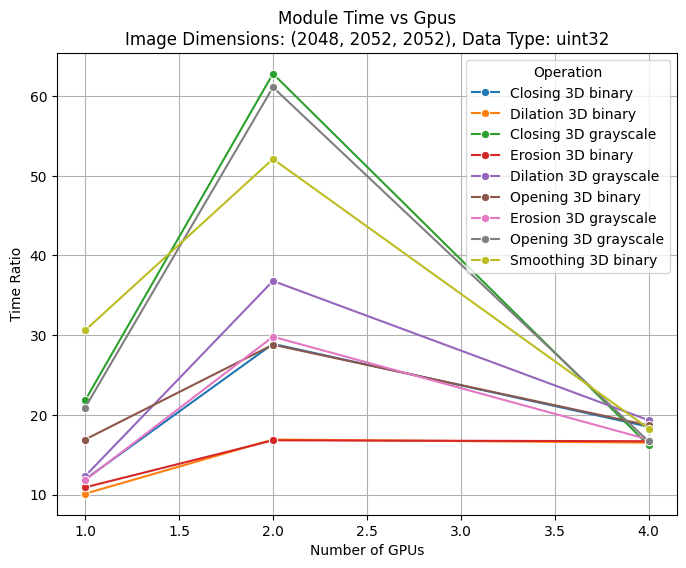

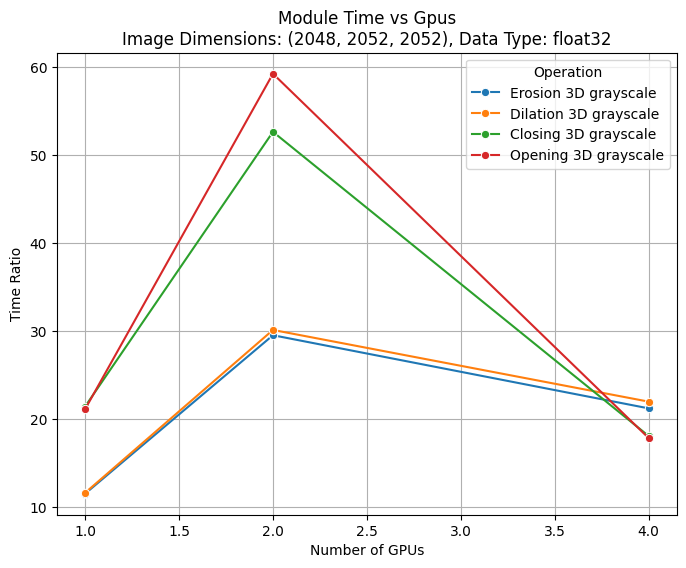

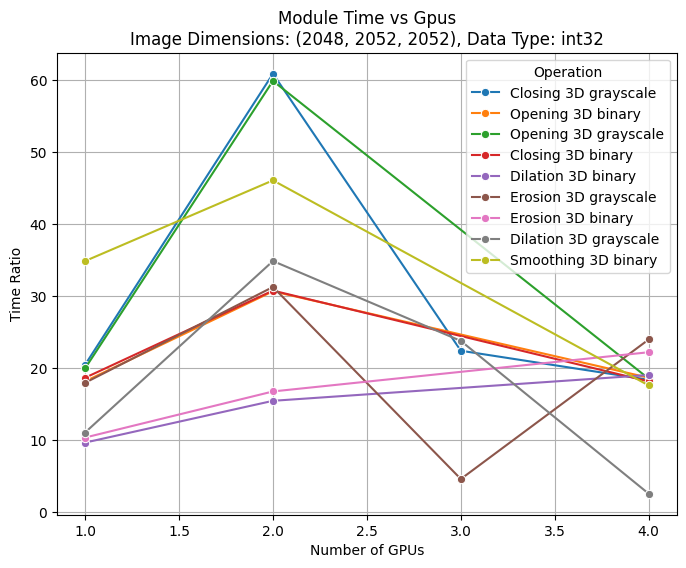

In [17]:
df_32 = df[(df['Image Dimensions'] == '(2048, 2052, 2052)') & df['Image Data Type'].isin(['uint32', 'float32', 'int32'])]

# Get unique values of 'Image Dimensions' and 'Image Data Type'
image_dims = df_32['Image Dimensions'].unique()
data_types = df_32['Image Data Type'].unique()

# Create plots for each combination of Image Dimensions and Image Data Type
for img_dim in ['(2048, 2052, 2052)']:
    for dtype in data_types:
        plt.figure(figsize=(8, 6))
        subset = df_32[(df_32['Image Dimensions'] == img_dim) & (df_32['Image Data Type'] == dtype)]

        sns.lineplot(data=subset, x='Gpus', y='Time Ratio', hue='Operation', marker='o')

        plt.title(f"Module Time vs Gpus\nImage Dimensions: {img_dim}, Data Type: {dtype}")
        plt.xlabel("Number of GPUs")
        plt.ylabel("Time Ratio")
        plt.legend(title="Operation")
        plt.grid(True)
        plt.show()

## Erro na operação cudaMemcpy(deviceToHost)

O parâmetro gpuMemory controla o quanto da memorória livre da gpu pode ser usado para alocar a imagem de entrada e suas cópias. A parir desse parâmetro, da memória livre e do númeor de cópias do input usado pela função, calcula-se o tamanho máximo do chunk. 
Em testes locais, usando a gpu do notebook, é possível operar com gpuMemory próximo de 1. É precisa fechar todas as demais janelas e manter apenas o terminal aberto para que o sistema operacional não mate o processo (pois a gpu também é usada para renderizar a interface gráfica e o sistema fica sobrecarregado).
Nos testes remotos feitos na Harriet, não é possível aumentar o parâmetro gpuMemory. Para a imagem média (1520, 1520, 600) o valor máximo da gpuMemory que é possível executar o código é 0.41. Para a imagem grande (2048, 2052, 2052) esse valor cai para 0.2, podendo variar a depender da operação e do tipo de dado.
Especialmente para a imagem grande (2048, 2052, 2052) e operações de erosão e dilatação em dados uint8 surgiam erros de 'segmentation fault' para qualquer valor de gpuMemory. Nos demais tipos de dados, surgia erro recorrente na função cudaMemcpy(deviceToHost), especificamente quando copiava-se o resultado final de algum chunk do device para o host a partir de um determinado valor de gpuMemory.
Foram identificadas duas hipóteses de problema:
1) **Dados não emparelhados na memória** - como o tipo de dado uint8 ocupa apenas 1 byte, poderia estar alocado na memória fora do padrão esperado pelas funções cuda e, por isso, surgia o erro 'segmentation fault'.
**Proposta de solução:** alocar os dado no host para testes com funções cuda (cudaMallocHost), pois a função lidaria internamente com esse problema.

2) **Taxa de transferência de dados maior do que a permitida para a função cudaMemcpy(deviceToHost)** 
**Proposta de solução:** copiar os dados em chunks ainda menores de volta para o host.

Foram realizados testes implementando cada uma dessas soluções separadamente e juntas para imagens uint8 e uint16 e os valores de gpuMemory 0.4 e 0.9

### Resultados:

#### CudaMallocHost 
**uint8:**  Funcionou para gpuMemory 0.4 e 0.9.
**uint16:** Não funcionou para gpuMemory 0.4, 0.9 não foi testado.

#### CopyChunks
**uint8:** Não funcionou para gpuMemory 0.4 nem 0.9.
**uint16:** Funcionou para gpuMemory 0.4, e não funcionou para 0.9.

#### CudaMallocHost + CopyChunks 
**uint8:**  Não funcionou para gpuMemory 0.4 nem 0.9.
**uint16:** Funcionou para gpuMemory 0.4 e 0.9

### Conclusão
As soluçoes foram inconclusivas, porque funcionavam para um tipo de dado e para outro não. Não foram implementadas ainda.